<a href="https://colab.research.google.com/github/jatindahiya1105-lang/Lung-Cancer-Detection-/blob/main/Lung_Cancer_Detection_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hamdallak/the-iqothnccd-lung-cancer-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'the-iqothnccd-lung-cancer-dataset' dataset.
Path to dataset files: /kaggle/input/the-iqothnccd-lung-cancer-dataset


In [2]:
import pandas as pd
import numpy as np
import keras
import warnings
warnings.filterwarnings(action="ignore")
import matplotlib.pyplot as plt
%matplotlib inline

from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Corrected import path
from tensorflow.keras.callbacks import TensorBoard,EarlyStopping

import sklearn.metrics as metrics
from keras.callbacks import LearningRateScheduler
# The following line is also corrected as ImageDataGenerator is already imported from tensorflow.keras
# from keras.preprocessing.image import ImageDataGenerator # This line is redundant or incorrect given the change above
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x, verbose=0)

In [3]:
import os
import pandas as pd

benign_dirs = [
    r'/kaggle/input/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Bengin cases'
]

Malignant_dir = [ r'/kaggle/input/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Malignant cases']

Normal_dirs = [
    r'/kaggle/input/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases'
]

filepaths = []
labels = []
dict_lists = [benign_dirs, Malignant_dir, Normal_dirs]
class_labels = ['benign', 'Malignant', 'Normal']

for i, dir_list in enumerate(dict_lists):
    for j in dir_list:
        flist = os.listdir(j)
        for f in flist:
            fpath = os.path.join(j, f)
            filepaths.append(fpath)
            labels.append(class_labels[i])

Fseries = pd.Series(filepaths, name="filepaths")
Lseries = pd.Series(labels, name="labels")
Lung_data = pd.concat([Fseries, Lseries], axis=1)
Lung_df = pd.DataFrame(Lung_data)
print(Lung_df.head())
print(Lung_df["labels"].value_counts())

                                           filepaths  labels
0  /kaggle/input/the-iqothnccd-lung-cancer-datase...  benign
1  /kaggle/input/the-iqothnccd-lung-cancer-datase...  benign
2  /kaggle/input/the-iqothnccd-lung-cancer-datase...  benign
3  /kaggle/input/the-iqothnccd-lung-cancer-datase...  benign
4  /kaggle/input/the-iqothnccd-lung-cancer-datase...  benign
labels
Malignant    561
Normal       416
benign       120
Name: count, dtype: int64


In [4]:
Lung_df.shape

(1097, 2)

In [5]:
train_images, test_images = train_test_split(Lung_df, test_size=0.3, random_state=42)
train_set, val_set = train_test_split(Lung_df, test_size=0.2, random_state=42)

In [6]:
print(train_set.shape)
print(test_images.shape)
print(val_set.shape)
print(train_images.shape)

(877, 2)
(330, 2)
(220, 2)
(767, 2)


In [7]:
image_gen = ImageDataGenerator(preprocessing_function= tf.keras.applications.mobilenet_v2.preprocess_input)
train = image_gen.flow_from_dataframe(dataframe= train_set,x_col="filepaths",y_col="labels",
                                      target_size=(244,244),
                                      color_mode='rgb',
                                      class_mode="categorical", #used for Sequential Model
                                      batch_size=4,
                                      shuffle=False            #do not shuffle data
                                     )
test = image_gen.flow_from_dataframe(dataframe= test_images,x_col="filepaths", y_col="labels",
                                     target_size=(244,244),
                                     color_mode='rgb',
                                     class_mode="categorical",
                                     batch_size=4,
                                     shuffle= False
                                    )
val = image_gen.flow_from_dataframe(dataframe= val_set,x_col="filepaths", y_col="labels",
                                    target_size=(244,244),
                                    color_mode= 'rgb',
                                    class_mode="categorical",
                                    batch_size=4,
                                    shuffle=False
                                   )

Found 877 validated image filenames belonging to 3 classes.
Found 330 validated image filenames belonging to 3 classes.
Found 220 validated image filenames belonging to 3 classes.


In [8]:
classes=list(train.class_indices.keys())
print (classes)

['Malignant', 'Normal', 'benign']


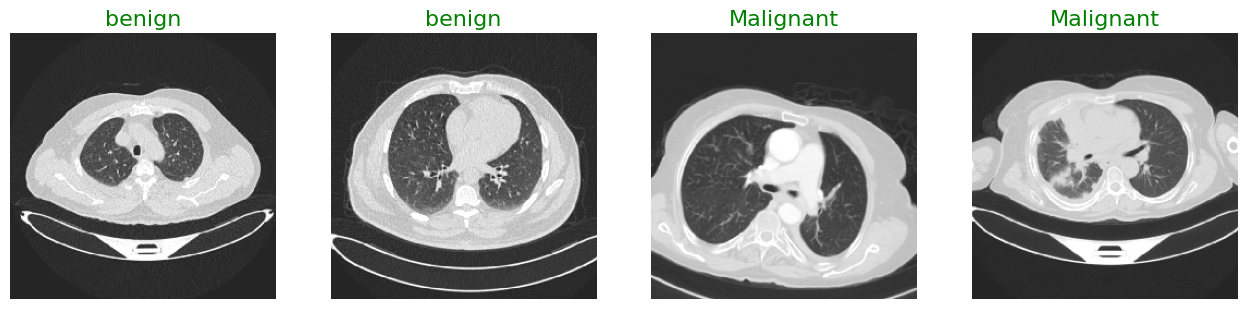

In [9]:
def show_knee_images(image_gen):
    test_dict = test.class_indices
    classes = list(test_dict.keys())
    images, labels=next(image_gen) # get a sample batch from the generator
    plt.figure(figsize=(20,20))
    length = len(labels)
    if length<25:
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5,5,i+1)
        image=(images[i]+1)/2 #scale images between 0 and 1
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color="green",fontsize=16)
        plt.axis('off')
    plt.show()
show_knee_images(train)

In [10]:
model = keras.models.Sequential([
    keras.layers.Conv2D(filters=128, kernel_size=(8, 8), strides=(3, 3), activation='relu', input_shape=(244, 244, 3)), # Changed input_shape to (244, 244, 3)
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(3, 3)),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(2, 2)),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.Flatten(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(3, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.optimizers.SGD(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 79, 79, 128)    │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 79, 79, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 79, 79, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 79, 79, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    88,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,998,531 (354.76 MB)

 Trainable params: 92,995,715 (354.75 MB)

 Non-trainable params: 2,816 (11.00 KB)

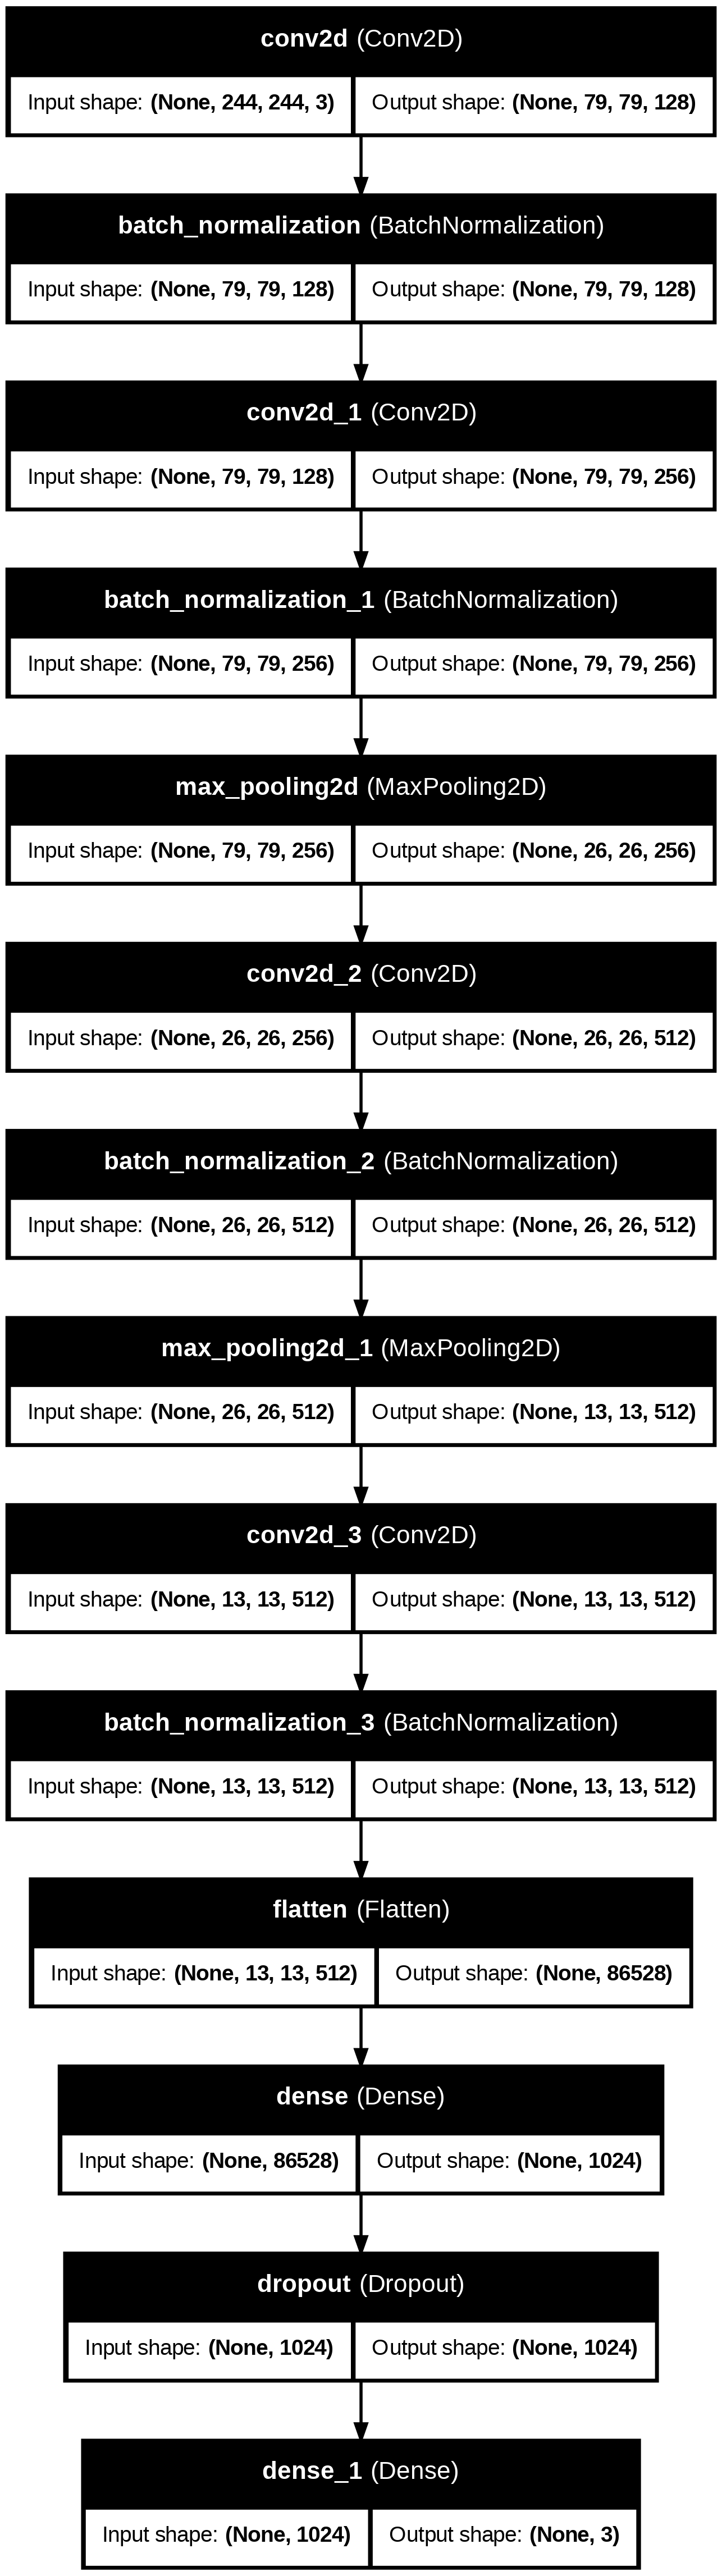

In [11]:
from keras.utils import plot_model

plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [12]:
history = model.fit(train, epochs=10, validation_data=val, verbose=1)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 29s 89ms/step - accuracy: 0.6240 - loss: 2.6692 - val_accuracy: 0.4955 - val_loss: 1.8476
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.8570 - loss: 0.4101 - val_accuracy: 0.8909 - val_loss: 0.2394
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.9647 - loss: 0.0876 - val_accuracy: 0.9818 - val_loss: 0.0489
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.9892 - loss: 0.0452 - val_accuracy: 0.9727 - val_loss: 0.0805
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.9937 - loss: 0.0193 - val_accuracy: 0.9955 - val_loss: 0.0133
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step - accuracy: 0.9961 - loss: 0.0176 - val_accuracy: 0.9909 - val_loss: 0.0449
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - accuracy: 0.9926 - loss: 0.0259 - val_accuracy: 0.9909 - val_loss: 0.0609
Epoch 8/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - accuracy: 0.9972 - loss: 0.0216 - 

In [13]:
model.evaluate(test, verbose=1)

83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9698 - loss: 0.1184


[0.03727385774254799, 0.9878787994384766]

In [15]:
pred = model.predict(test)
pred = np.argmax(pred, axis=1) #pick class with highest  probability

labels = (train.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred2 = [labels[k] for k in pred]

83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step


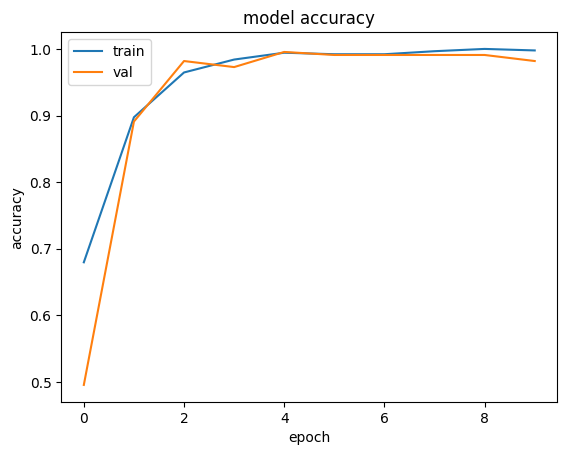

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

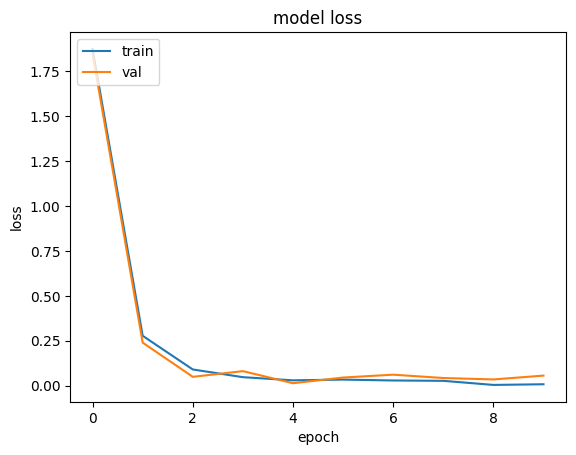

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_test = test_images.labels # set y_test to the expected output
print(classification_report(y_test, pred2))
print("Accuracy of the Model:","{:.1f}%".format(accuracy_score(y_test, pred2)*100))

              precision    recall  f1-score   support

   Malignant       0.99      1.00      1.00       174
      Normal       0.97      0.99      0.98       116
      benign       1.00      0.93      0.96        40

    accuracy                           0.99       330
   macro avg       0.99      0.97      0.98       330
weighted avg       0.99      0.99      0.99       330

Accuracy of the Model: 98.8%


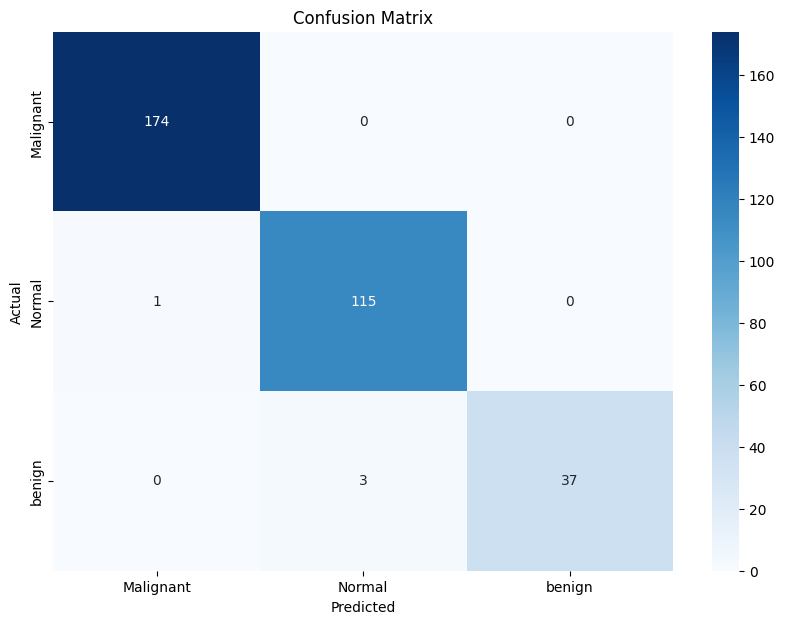

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_labels = ['Malignant', 'Normal', 'benign']

cm = confusion_matrix(y_test, pred2)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues')

plt.xticks(ticks=[0.5, 1.5, 2.5], labels=class_labels)
plt.yticks(ticks=[0.5, 1.5, 2.5], labels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


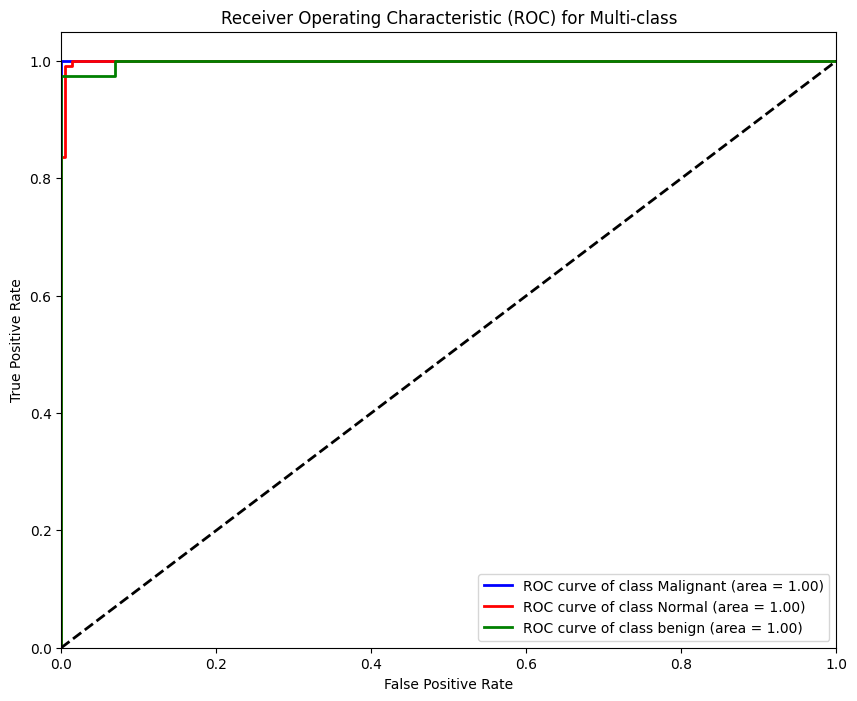

In [24]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Get prediction probabilities for the test set
# (Assuming 'test' is your generator and 'model' is your trained model)
probs = model.predict(test)

# 2. Binarize the true labels for multi-class ROC calculation
# 'classes' was defined earlier as ['Malignant', 'Normal', 'benign']
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = y_test_binarized.shape[1]

# 3. Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Multi-class')
plt.legend(loc="lower right")
plt.show()

In [25]:
from sklearn.metrics import roc_auc_score

# Calculate macro-average AUC
macro_auc = roc_auc_score(y_test_binarized, probs, average='macro', multi_class='ovr')

# Calculate micro-average AUC
micro_auc = roc_auc_score(y_test_binarized, probs, average='micro', multi_class='ovr')

print(f"Overall Macro-Average AUC: {macro_auc:.4f}")
print(f"Overall Micro-Average AUC: {micro_auc:.4f}")

Overall Macro-Average AUC: 0.9991
Overall Micro-Average AUC: 0.9993


In [26]:
model.save("lung_cancer_detection_model.keras")

In [27]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_lung_cancer(img_path, model):

    img = image.load_img(img_path, target_size=(224,224), color_mode="grayscale")
    img = image.img_to_array(img)

    img = np.repeat(img, 3, axis=2)   # convert grayscale → RGB
    img = img / 255.0

    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)[0][0]

    if prediction > 0.5:
        return "Cancer Detected", prediction
    else:
        return "Normal", 1 - prediction

In [29]:
!pip install -q streamlit
import streamlit as st
from tensorflow.keras.models import load_model
from PIL import Image

# Updated filename to match the saved model in cell ZtsjCHldt0dg
model = load_model("lung_cancer_detection_model.keras")

st.title("AI Lung Cancer Detection System")

uploaded_file = st.file_uploader("Upload CT Scan", type=["jpg","png","jpeg"])

if uploaded_file is not None:
    img = Image.open(uploaded_file)
    st.image(img, caption="Uploaded CT Scan")

    result, confidence = predict_lung_cancer(uploaded_file, model)

    st.write("Prediction:", result)
    st.write("Confidence:", float(confidence))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 139.7 MB/s eta 0:00:00


2026-03-04 12:04:33.069 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 12:04:33.348 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-04 12:04:33.349 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 12:04:33.349 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 12:04:33.351 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 12:04:33.352 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 12:04:33.354 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 12:04:33.355 Thread 'MainThread': mi

In [32]:
from sklearn.metrics import classification_report, accuracy_score

# Ensure y_test and pred2 are current
print("Classification Report:")
print(classification_report(y_test, pred2))

accuracy = accuracy_score(y_test, pred2)
print(f"Overall Accuracy: {accuracy*100:.2f}%")

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.99      1.00      1.00       174
      Normal       0.97      0.99      0.98       116
      benign       1.00      0.93      0.96        40

    accuracy                           0.99       330
   macro avg       0.99      0.97      0.98       330
weighted avg       0.99      0.99      0.99       330

Overall Accuracy: 98.79%
